# Titre

## Création des échantillons train et test

Divisez le jeu de données en un échantillon d’apprentissage et un échantillon test. Vous prendrez un pourcentage de 20% pour l’échantillon test. Pourquoi cette étape est-elle nécessaire lorsque nous nous concentrons sur les performances des algorithmes ?

Le fait d'entraîner et de tester le modèle sur deux échantillons distincts permet de tester ses véritables performances face à des données nouvelles. Si l'on testait sur l'échantillon d'apprentissage, les performances seraient artificiellement meilleures et nous ne pourrions pas détecter un surapprentissage éventuel.

In [11]:
import pandas as pd
import numpy as np

seed = 42  #seed pour la reproductibilité

In [12]:
df = pd.read_csv('healthcare_synthetic_data.csv')
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [13]:
#On remarque que les données quali sont deja encodées nuémriquement (0,1,2)
#On enlève Patient_ID car inutile
df = df.drop(columns=['Patient_ID'])

# Listes par type de variable
quant_vars = ['Age','Height_cm','Weight_kg','BMI','Systolic_BP','Diastolic_BP',
              'Cholesterol_Total','Cholesterol_LDL','Cholesterol_HDL',
              'Fasting_Blood_Sugar','Stress_Level','Sleep_Hours']
qual_vars  = ['Gender','Smoking_Status','Alcohol_Consumption',
              'Physical_Activity_Level','Family_History']
var_cls = 'Heart_Disease_Risk'  #Variable à classifier
var_reg = 'Cholesterol_LDL'  #Variable pour la régression

print("Variables quantitatives :", quant_vars)
print("Variables qualitatives (encodées) :", qual_vars)
print("Cibles :", var_cls, '|', var_reg)

Variables quantitatives : ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours']
Variables qualitatives (encodées) : ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History']
Cibles : Heart_Disease_Risk | Cholesterol_LDL


In [14]:
#Division des données en train (80%) et test (20%) pour la CLASSIFICATION
from sklearn.model_selection import train_test_split
df_cls = df.copy()  #On crée une copie du df original pour la classif

features_cls = [c for c in df_cls.columns if c != var_cls]  #On crée une liste des features pour la cls (toutes les var sauf Heart_disease')
X_cls = df_cls[features_cls]
y_cls = df_cls[var_cls]

# Division 80/20
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=seed, stratify=y_cls)  #stratify=y_cls permet de garantir que chaque classe est bien représentée dans le train et test

In [15]:
#Division des données en train (80%) et test (20%) pour la RÉGRESSION
from sklearn.model_selection import train_test_split
df_reg = df.copy()  #On crée une copie du df original pour la classif

features_reg = [c for c in df_cls.columns if c != var_cls and c!=var_reg]  #On crée une liste des features pour la reg (toutes les var sauf Heart_disease' et 'cholesterol_ldl')
X_reg = df_reg[features_reg]
y_reg = df_reg[var_reg]

# Division 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=seed)  #stratify marche pas ici car var_reg est continue


In [16]:
## ATTENTION: Il faut normaliser les données
from sklearn.preprocessing import StandardScaler 

#Classification
scaler = StandardScaler()  
scaler.fit(X_train_c)  
Xr_train_c = scaler.transform(X_train_c)  
# Meme transformation sur le test
Xr_test_c = scaler.transform(X_test_c)

#Régression
scaler = StandardScaler()  
scaler.fit(X_train_r)  
Xr_train_r = scaler.transform(X_train_r)  
# Meme transformation sur le test
Xr_test_r = scaler.transform(X_test_r)

## A. Modèles de classification

### I. Modèles linéaires

#### I. a) Régression logistique (GLM)

In [38]:
#On commence par un GLM classique pour la cls : la régression logistique.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(solver="liblinear"), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(Xr_train_c, y_train_c)  # GridSearchCV est lui-même un estimateur
# paramètre optimal

# Prévision
y__pred_logit = logitOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y__pred_logit,y_test_c)
print(table)
#C'est pas ouf

print(f"Meilleur C (Logit): {logitOpt.best_params_['C']}")
print(f"Accuracy CV (train, Logit): {logitOpt.best_score_*100:.4f}%")
acc_test = accuracy_score(y_test_c, y__pred_logit)
print(f"Accuracy test (Logit) : {acc_test*100:.4f}%")

Heart_Disease_Risk     0    1
row_0                        
0                   1375  467
1                    317  841
Meilleur C (Logit): 0.01
Accuracy CV (train, Logit): 73.8417%
Accuracy test (Logit) : 73.8667%


#### I. b) Ridge (pénalisation sans sélection de variables)

Heart_Disease_Risk     0    1
row_0                        
0                   1375  467
1                    317  841
Meilleur C (L2) : 0.01
Accuracy CV (train, L2) : 73.8417%
Accuracy test (L2) : 73.8667%
Coefficients de Ridge : [ 2.31616900e-01 -3.08950223e-02 -3.66611940e-02  9.74895149e-02
  1.13224169e-01  3.11639173e-01  1.13683956e-04  8.14219025e-03
  1.59726676e-01 -3.79377015e-02  2.87969283e-01  8.60591446e-01
 -1.14898533e-02 -4.24968474e-01  4.97882752e-01  2.76442781e-01
 -8.63310673e-02]


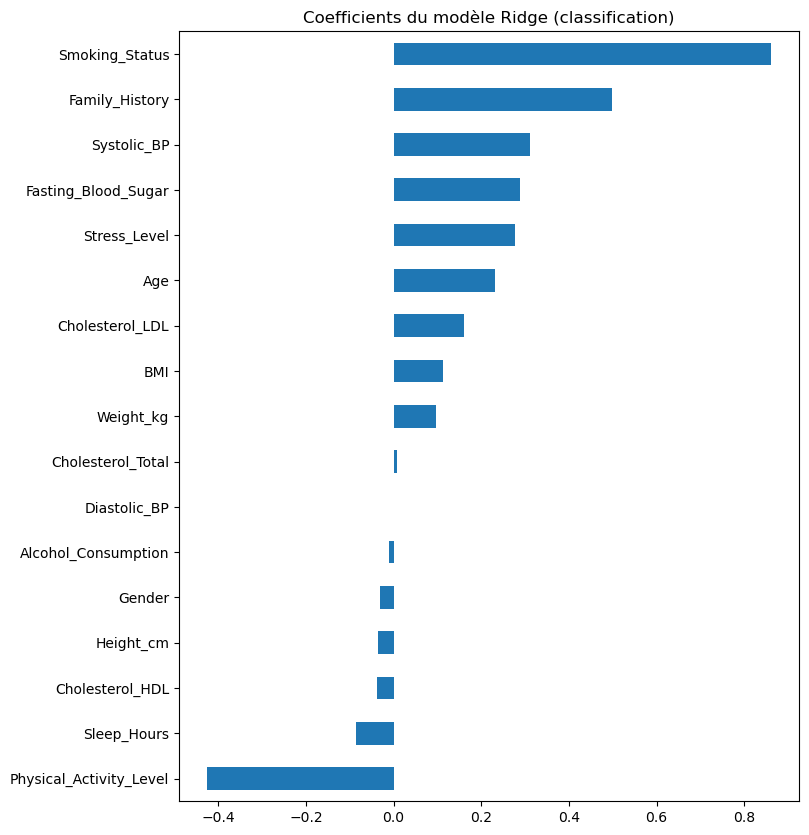

In [37]:
#On continue sur de la pénalisation sans sélection de variables : Ridge
import matplotlib.pyplot as plt

# Grille d'hyperparamètres (C = 1/λ)
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}

ridge = GridSearchCV(LogisticRegression(penalty="l2", solver="liblinear"),param,cv=5,n_jobs=-1)

ridge.fit(Xr_train_c, y_train_c)

# Prédictions du modèle Ridge logistique
y_pred_ridge = ridge.best_estimator_.predict(Xr_test_c)
# Table de prédiction
table = pd.crosstab(y_pred_ridge, y_test_c)
print(table)
#Aussi nul que logit classique EXACTEMENT

print(f"Meilleur C (L2) : {ridge.best_params_['C']}")
print(f"Accuracy CV (train, L2) : {ridge.best_score_*100:.4f}%")
acc_test = accuracy_score(y_test_c, y_pred_ridge)
print(f"Accuracy test (L2) : {acc_test*100:.4f}%")

#La régression logistique pénalisée L2 (Ridge) donne des performances identiques à la régression logistique simple.
#Cela est cohérent : la pénalisation L2 stabilise les coefficients mais ne modifie pas la frontière de décision.
#Dans notre dataset, les variables sont bien conditionnées et la logit simple n’est pas sujette au surapprentissage, ce qui explique l’absence de gain en accuracy. 

# Coefficients du meilleur modèle
ridgeCoef = ridge.best_estimator_.coef_[0]
print(f"Coefficients de Ridge : {ridgeCoef}")

coef = pd.Series(ridgeCoef, index=X_train_c.columns)


# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle Ridge (classification)")
plt.show()

#### I. c) LASSO (pénalisation avec sélection de variables)

Heart_Disease_Risk     0    1
row_0                        
0                   1373  462
1                    319  846
Meilleur C (L1) : 0.05
Accuracy CV (train, L1) : 73.8417%
Accuracy test (L1) : 73.9667%
Lasso conserve 14 variables et en supprime 3


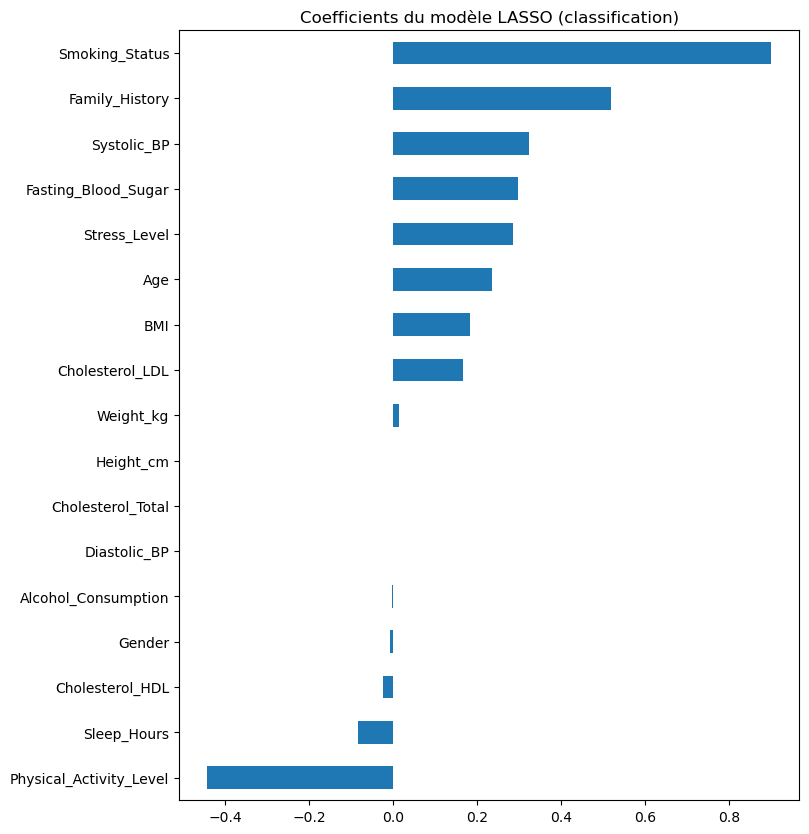

In [40]:
#On continue sur de la pénalisation avec sélection de variables : LASSO

# Grille d'hyperparamètres
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}

lasso = GridSearchCV(LogisticRegression(penalty="l1", solver="liblinear"),param,cv=5,n_jobs=-1)

lasso.fit(Xr_train_c, y_train_c)

# Prédictions du modèle LASSO logistique
y_pred_lasso = lasso.best_estimator_.predict(Xr_test_c)
# Table de prédiction
table = pd.crosstab(y_pred_lasso, y_test_c)
print(table)
#Aussi nul que logit classique

print(f"Meilleur C (L1) : {lasso.best_params_['C']}")
print(f"Accuracy CV (train, L1) : {lasso.best_score_*100:.4f}%")
acc_test = accuracy_score(y_test_c, y_pred_lasso)
print(f"Accuracy test (L1) : {acc_test*100:.4f}%")

# Coefficients du meilleur modèle
lassoCoef = lasso.best_estimator_.coef_[0]

# IMPORTANT : X_train_c doit être un DataFrame (pas .values)
coef = pd.Series(lassoCoef, index=X_train_c.columns)

print("Lasso conserve", sum(coef != 0),
      "variables et en supprime", sum(coef == 0))

# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle LASSO (classification)")
plt.show()

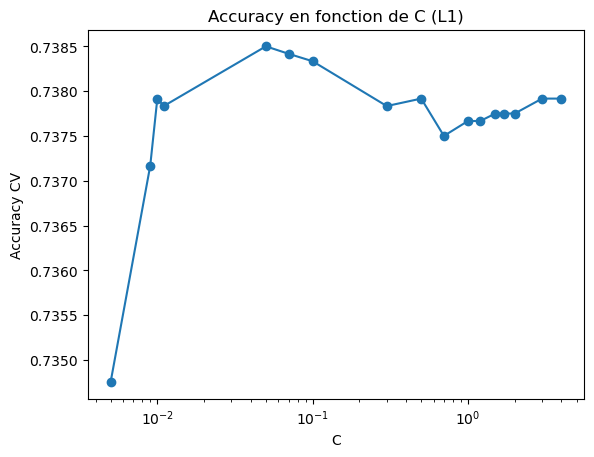

In [23]:
#ON SAIT PAS INTERPRÉTER
mean_scores = lasso.cv_results_['mean_test_score']
Cs = param["C"]

plt.plot(Cs, mean_scores, marker='o')
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy CV")
plt.title("Accuracy en fonction de C (L1)")
plt.show()



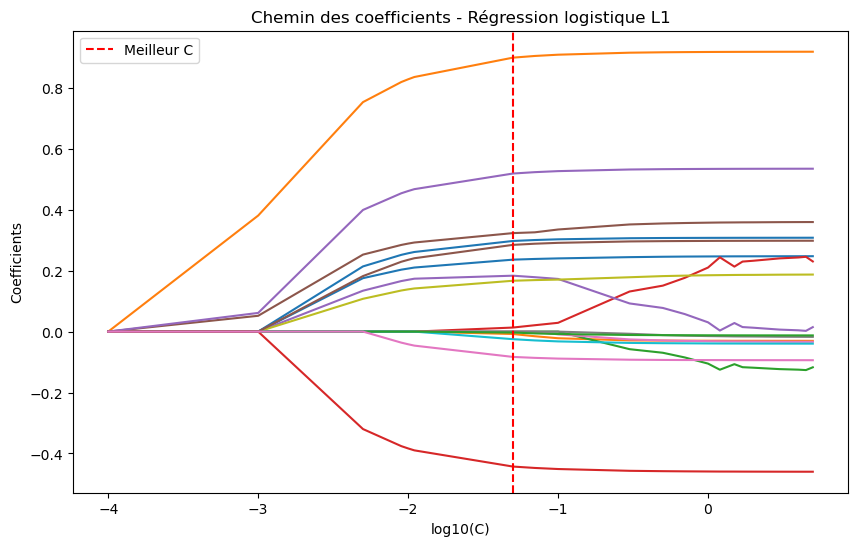

In [24]:
#On est obligé de ré entrainer un modele afin de récupérer les valeurs des coeff pour chaque C
Cs = [0.0001,0.001,0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4,4.5,5]  #on rajoute 0.0001,0.001, et ,4.5,5 pour la visualisation
coefs = []

for C in Cs:
    clf = LogisticRegression(penalty="l1", solver="liblinear", C=C)
    clf.fit(Xr_train_c, y_train_c)
    coefs.append(clf.coef_.ravel())

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
plt.plot(np.log10(Cs), coefs)
plt.xlabel("log10(C)")
plt.ylabel("Coefficients")
plt.title("Chemin des coefficients - Régression logistique L1")
plt.axvline(np.log10(lasso.best_params_['C']), color='red', linestyle='--', label='Meilleur C')
plt.legend()
plt.show()


#### I. d) Elastic Net

Heart_Disease_Risk     0    1
row_0                        
0                   1379  466
1                    313  842
Meilleur C (Elastic Net) : 0.05
Accuracy CV (train, Elastic Net) : 73.8417%
Accuracy test (Elastic Net) : 74.0333%
Coefficients de Elastic Net : [ 0.23924575 -0.02244551  0.          0.03044989  0.17100162  0.33025945
 -0.00530619  0.          0.16998877 -0.03218575  0.30115473  0.9030301
 -0.00788195 -0.44785157  0.52299811  0.289329   -0.08788785]


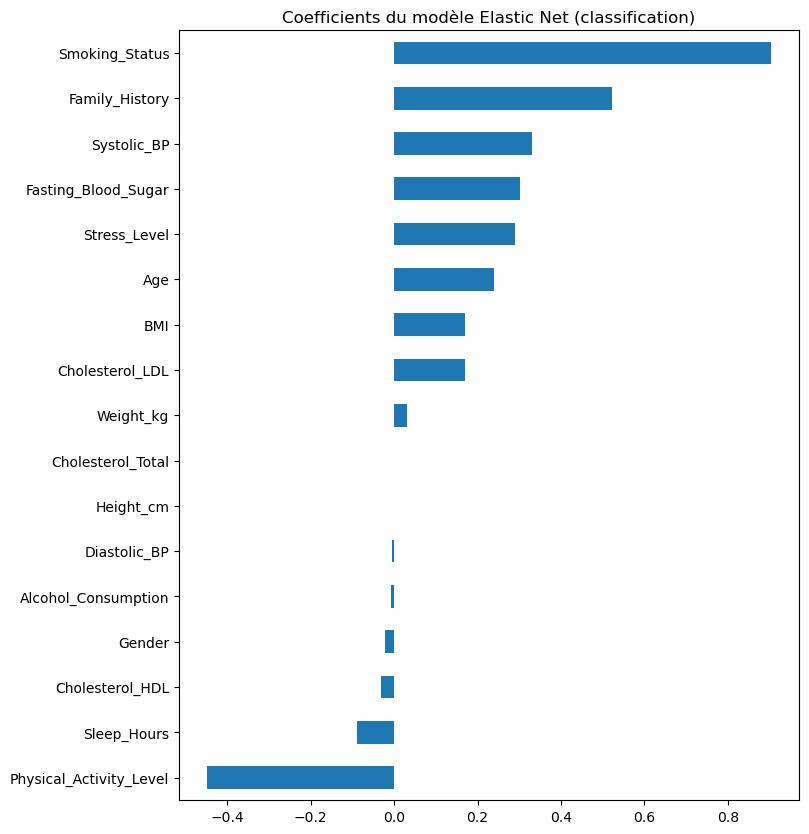

In [41]:
# Grille d'hyperparamètres (C = 1/λ)
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}

ela = GridSearchCV(LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5),param,cv=5,n_jobs=-1)  #l1_ratio ???

ela.fit(Xr_train_c, y_train_c)

# Prédictions du modèle Elastic Net logistique
y_pred_ela = ela.best_estimator_.predict(Xr_test_c)
# Table de prédiction
table = pd.crosstab(y_pred_ela, y_test_c)
print(table)

print(f"Meilleur C (Elastic Net) : {ela.best_params_['C']}")
print(f"Accuracy CV (train, Elastic Net) : {ela.best_score_*100:.4f}%")
acc_test = accuracy_score(y_test_c, y_pred_ela)
print(f"Accuracy test (Elastic Net) : {acc_test*100:.4f}%")

#La régression logistique pénalisée L2 (Ridge) donne des performances identiques à la régression logistique simple.
#Cela est cohérent : la pénalisation L2 stabilise les coefficients mais ne modifie pas la frontière de décision.
#Dans notre dataset, les variables sont bien conditionnées et la logit simple n’est pas sujette au surapprentissage, ce qui explique l’absence de gain en accuracy. 

# Coefficients du meilleur modèle
elaCoef = ela.best_estimator_.coef_[0]
print(f"Coefficients de Elastic Net : {elaCoef}")

coef = pd.Series(elaCoef, index=X_train_c.columns)


# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle Elastic Net (classification)")
plt.show()

### II. Support Vector

Pour la tâche de classification, nous ne pouvons utiliser que SVC et non SVR.

#### II. a) SVM avec kernel RBF

In [13]:
from sklearn.svm import SVC

param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm= GridSearchCV(SVC(kernel="rbf"),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xr_train_c, y_train_c)
# paramètre optimal
print(f"Meilleur C (SVM): {svmOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM): {svmOpt.best_score_*100:.4f}%")

Meilleur C (SVM): 0.7
Accuracy CV (train, SVM): 72.9417%


In [14]:
# prévision de l'échantillon test
y_chap = svmOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y_chap,y_test_c)
print(table)

#Plus nul que les autres

Heart_Disease_Risk     0    1
row_0                        
0                   1384  493
1                    308  815


#### II. b) SVM avec kernel linéaire

In [15]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_l= GridSearchCV(SVC(kernel="linear"),param,cv=10,n_jobs=-1)
svm_lOpt=svm_l.fit(Xr_train_c, y_train_c)
# paramètre optimal
print(f"Meilleur C (SVM Linéaire): {svm_lOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM linéaire): {svm_lOpt.best_score_*100:.4f}%")

Meilleur C (SVM Linéaire): 0.3
Accuracy CV (train, SVM linéaire): 73.2250%


In [16]:
# prévision de l'échantillon test
y_chap = svm_lOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y_chap,y_test_c)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1361  492
1                    331  816


#### II. c) SVM avec kernel polynomial

In [17]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_p= GridSearchCV(SVC(kernel="poly"),param,cv=10,n_jobs=-1)
svm_pOpt=svm_p.fit(Xr_train_c, y_train_c)
# paramètre optimal
print(f"Meilleur C (SVM Polynomial): {svm_pOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Polynomial): {svm_pOpt.best_score_*100:.4f}%")

Meilleur C (SVM Polynomial): 0.3
Accuracy CV (train, SVM Polynomial): 73.1667%


In [18]:
# prévision de l'échantillon test
y_chap = svm_pOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y_chap,y_test_c)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1409  549
1                    283  759


#### II. d) SVM avec kernel sigmoid

In [19]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_s= GridSearchCV(SVC(kernel="sigmoid"),param,cv=10,n_jobs=-1)
svm_sOpt=svm_s.fit(Xr_train_c, y_train_c)
# paramètre optimal
print(f"Meilleur C (SVM Sigmoid): {svm_sOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Sigmoid): {svm_sOpt.best_score_*100:.4f}%")

Meilleur C (SVM Sigmoid): 0.011
Accuracy CV (train, SVM Sigmoid): 73.0083%


In [20]:
# prévision de l'échantillon test
y_chap = svm_sOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y_chap,y_test_c)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1407  541
1                    285  767


 Les différents noyaux du SVM (linéaire, RBF, polynomial, sigmoid) donnent des performances très proches de la régression logistique (~73 %).
Cela s’explique par la structure quasi linéaire du dataset : les variables sont suffisamment informatives pour qu’un modèle linéaire atteigne déjà le maximum de performance possible.
Les kernels non linéaires n’apportent donc pas de gain significatif. 

### III. Arbre optimal, Random Forest, Boosting

#### III. a) Arbre optimal

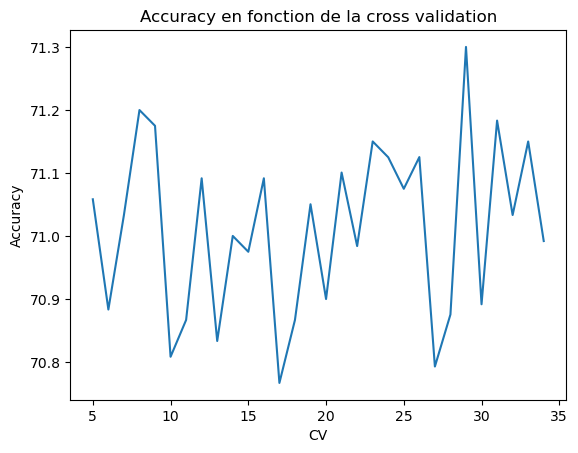

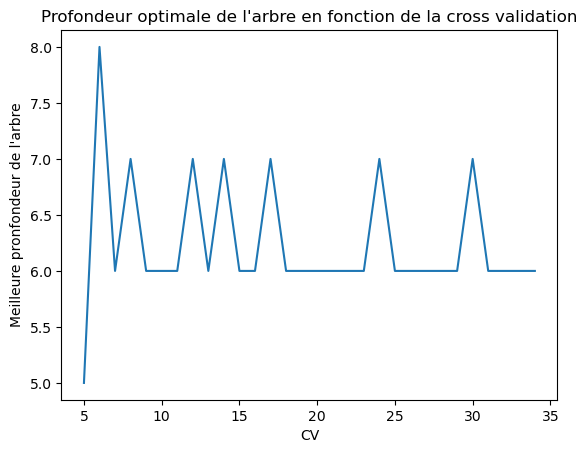

In [38]:
from sklearn.tree import DecisionTreeClassifier
cv_val = []
acc = []
dep = []

for cv in range(5,35):
    cv_val.append(cv)
    # Optimisation de la profondeur de l'arbre
    param=[{"max_depth":list(range(2,15))}]
    tree= GridSearchCV(DecisionTreeClassifier(),param,cv=cv,n_jobs=-1)
    treeOpt=tree.fit(Xr_train_c, y_train_c)
    acc.append(treeOpt.best_score_*100)
    dep.append(treeOpt.best_params_['max_depth'])
    
    #print(f"Meilleure profondeur (Arbre Optimal): {treeOpt.best_params_['max_depth']}")
    #print(f"Accuracy CV (train, Arbre Optimal): {treeOpt.best_score_*100:.4f}%")
plt.plot(cv_val,acc)
plt.xlabel("CV")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de la cross validation")
plt.show()

plt.plot(cv_val,dep)
plt.xlabel("CV")
plt.ylabel("Meilleure pronfondeur de l'arbre")
plt.title("Profondeur optimale de l'arbre en fonction de la cross validation")
plt.show()


#On voit bien que l'arbre optimal est instable : en fonction du nb de fold dans la CV, l'accuracy change bcp... On choisit donc une CV à 10 pour l'abre optimal car c'est standard et garantit que les folds ne sont pas trop petits

In [46]:
# Optimisation de la profondeur de l'arbre
param=[{"max_depth":list(range(2,15))}]
tree= GridSearchCV(DecisionTreeClassifier(),param,cv=10,n_jobs=-1)
treeOpt=tree.fit(Xr_train_c, y_train_c)

    
print(f"Meilleure profondeur (Arbre Optimal): {treeOpt.best_params_['max_depth']}")
print(f"Accuracy CV (train, Arbre Optimal): {treeOpt.best_score_*100:.4f}%")

Meilleure profondeur (Arbre Optimal): 6
Accuracy CV (train, Arbre Optimal): 70.8167%


In [41]:
y_chap = treeOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y_chap,y_test_c)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1403  574
1                    289  734


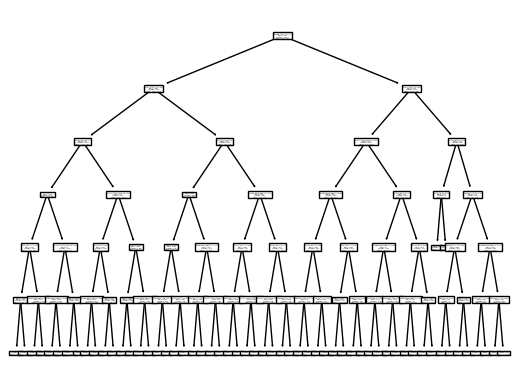

In [88]:
from sklearn.tree import plot_tree

treeG=DecisionTreeClassifier(max_depth=treeOpt.best_params_['max_depth'])
treeG.fit(Xr_train_c,y_train_c)
plot_tree(treeG,feature_names=df_cls.columns.tolist());
plt.show()


#On voit rien...

#### III. b) Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier 

param=[{"max_features":list(range(2,10,1))}]
rf= GridSearchCV(RandomForestClassifier(n_estimators=100),param,cv=10,n_jobs=-1)
rfOpt=rf.fit(Xr_train_c, y_train_c)

print(f"Meilleure profondeur (Arbre Optimal): {rfOpt.best_params_['max_features']}")
print(f"Accuracy CV (train, Arbre Optimal): {rfOpt.best_score_*100:.4f}%")

Meilleure profondeur (Arbre Optimal): 3
Accuracy CV (train, Arbre Optimal): 72.7333%


In [52]:
# prévision
y_chap = rfOpt.predict(Xr_test_c)
# matrice de confusion
table=pd.crosstab(y_chap,y_test_c)
print(table)

#pas ouf

Heart_Disease_Risk     0    1
row_0                        
0                   1381  508
1                    311  800


Smoking_Status 0.10676895620336614
Fasting_Blood_Sugar 0.07751741562932915
Systolic_BP 0.07499256679905836
Weight_kg 0.07365370737888217
Age 0.07328341701402172
BMI 0.07314402512331583
Cholesterol_Total 0.07101012636537547
Cholesterol_LDL 0.06960971708100441
Height_cm 0.06902733887878568
Diastolic_BP 0.06479944148576744
Cholesterol_HDL 0.05727374514543511
Stress_Level 0.05024894058961846
Physical_Activity_Level 0.03886988830158053
Sleep_Hours 0.035330731404769146
Family_History 0.033622250418825876
Alcohol_Consumption 0.019745681362242633
Gender 0.011102050818621898


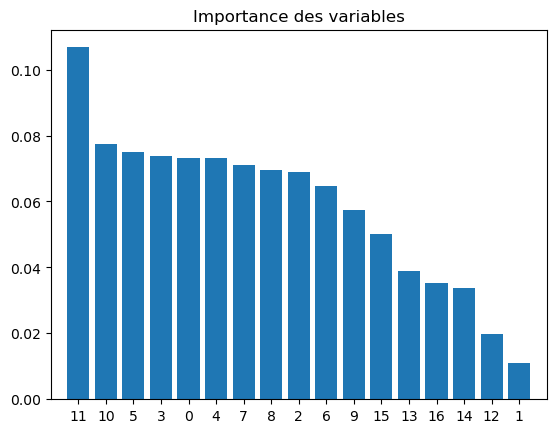

In [58]:
rf= RandomForestClassifier(n_estimators=100,max_features=2)
rfFit=rf.fit(Xr_train_c, y_train_c)
# Importance décroissante des variables
importances = rfFit.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(Xr_train_c.shape[1]):
    print(df_cls.columns[indices[f]], importances[indices[f]])


plt.figure()
plt.title("Importance des variables")
plt.bar(range(Xr_train_c.shape[1]), importances[indices]);
plt.xticks(range(Xr_train_c.shape[1]), indices);
plt.xlim([-1, Xr_train_c.shape[1]]);
plt.show()

#### III. c) Boosting ????

In [ ]:
#idk

### IV. Neural Networks

In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

n_features = Xr_train_c.shape[1]
n_classes = 2


In [127]:
keras_model = Sequential()
keras_model.add(Dense(n_hidden, input_dim=n_features, activation='sigmoid'))
keras_model.add(Dense(n_classes, activation='softmax'))

keras_model.compile(optimizer=SGD(learning_rate=0.3),
                    loss='categorical_crossentropy', metrics=['accuracy'])

history = keras_model.fit(Xr_train_c, to_categorical(y_train_c), epochs=15, batch_size=32, validation_data = (Xr_test_c, to_categorical(y_test_c)))

Epoch 1/15


I0000 00:00:1776258405.525071   39656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_296204__.16


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7057 - loss: 0.5754 - val_accuracy: 0.7313 - val_loss: 0.5463
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7353 - loss: 0.5368 - val_accuracy: 0.7353 - val_loss: 0.5383
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7379 - loss: 0.5351 - val_accuracy: 0.7347 - val_loss: 0.5374
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7347 - loss: 0.5343 - val_accuracy: 0.7403 - val_loss: 0.5384
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7372 - loss: 0.5334 - val_accuracy: 0.7330 - val_loss: 0.5389
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7353 - loss: 0.5340 - val_accuracy: 0.7337 - val_loss: 0.5406
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7368 - loss: 0.5334 - val_accuracy: 0.7347 - val_loss: 0.5369
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7358 - loss: 0.5333 - val_accuracy: 0.7307 - val_

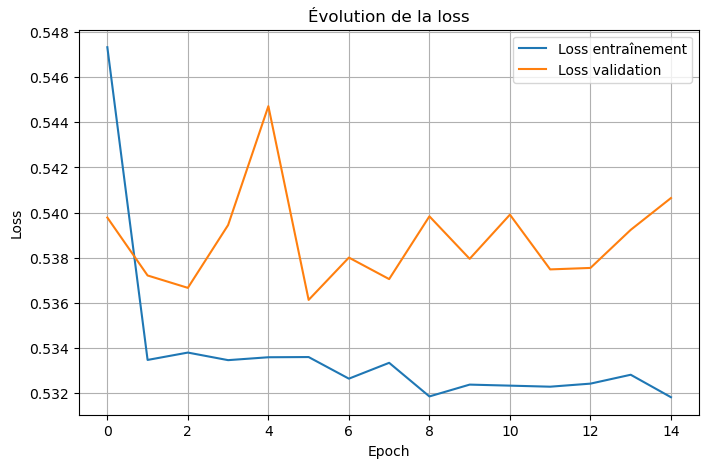

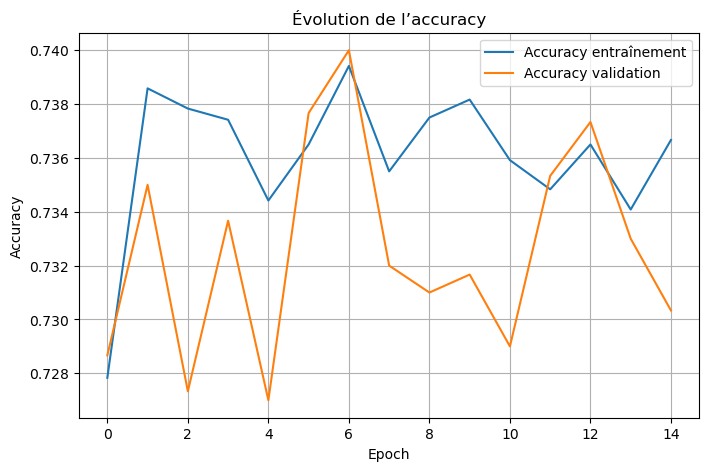

In [126]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss entraînement')
plt.plot(history.history['val_loss'], label='Loss validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution de la loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Accuracy entraînement')
plt.plot(history.history['val_accuracy'], label='Accuracy validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Évolution de l’accuracy')
plt.legend()
plt.grid(True)
plt.show()


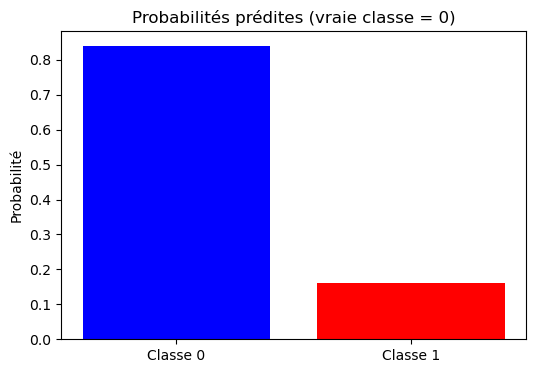

In [103]:
sample_idx = 42

probabilities = keras_model.predict(Xr_test_c, verbose=0)[sample_idx]

plt.figure(figsize=(6,4))
plt.bar([0,1], probabilities, color=["blue","red"])
plt.xticks([0,1], ["Classe 0", "Classe 1"])
plt.title(f"Probabilités prédites (vraie classe = {y_test_c.iloc[sample_idx]})")
plt.ylabel("Probabilité")
plt.show()



In [128]:
#On veut savoir combien mettre de hidden layers
results_mean = []
results_std = []
hidden_list = range(1, 10)

for n_hidden in hidden_list:
    accuracies = []
    
    for i in range(10):
        keras_model = Sequential()
        keras_model.add(Dense(n_hidden, input_dim=n_features, activation='sigmoid'))
        keras_model.add(Dense(n_classes, activation='softmax'))

        keras_model.compile(optimizer=SGD(learning_rate=0.3),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

        keras_model.fit(Xr_train_c, to_categorical(y_train_c),
                        epochs=15, batch_size=32, verbose=0,
                        validation_data=(Xr_test_c, to_categorical(y_test_c)))

        _, acc = keras_model.evaluate(Xr_test_c, to_categorical(y_test_c), verbose=0)  #On récupère la val_accuracy du modele
        accuracies.append(acc)

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    results_mean.append(mean_acc)
    results_std.append(std_acc)

    print(f"{n_hidden} neurones : accuracy moyenne = {mean_acc:.4f}, écart-type = {std_acc:.4f}")


1 neurones : accuracy moyenne = 0.7340, écart-type = 0.0036


I0000 00:00:1776258969.097132   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_622872__.16
I0000 00:00:1776258976.299797   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_652602__.16
I0000 00:00:1776258983.450822   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_682332__.16
I0000 00:00:1776258990.652744   39652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_712062__.16
I0000 00:00:1776258997.862542   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_741792__.16
I0000 00:00:1776259005.115542   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_771522__.16
I0000 00:00:1776259012.337182   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_801252__.16
I0000 00:00:1776259019.606986   39652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_d

2 neurones : accuracy moyenne = 0.7349, écart-type = 0.0041


I0000 00:00:1776259041.295930   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_920172__.16
I0000 00:00:1776259048.569199   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_949902__.16
I0000 00:00:1776259055.764964   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_979632__.16
I0000 00:00:1776259063.018619   39652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1009362__.16
I0000 00:00:1776259070.270789   39655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1039092__.16
I0000 00:00:1776259077.510145   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1068822__.16
I0000 00:00:1776259084.863754   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1098552__.16
I0000 00:00:1776259092.171971   39652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_

3 neurones : accuracy moyenne = 0.7348, écart-type = 0.0042


...

12 neurones : accuracy moyenne = 0.7297, écart-type = 0.0045


I0000 00:00:1776259786.510750   39652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3893172__.16
I0000 00:00:1776259794.253920   39655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3922902__.16
I0000 00:00:1776259801.616770   39656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3952632__.16
I0000 00:00:1776259808.968477   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3982362__.16
I0000 00:00:1776259816.252513   39656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4012092__.16
I0000 00:00:1776259823.596128   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4041822__.16
I0000 00:00:1776259830.835064   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4071552__.16
I0000 00:00:1776259838.163013   39656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

13 neurones : accuracy moyenne = 0.7325, écart-type = 0.0032


I0000 00:00:1776259860.219234   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4190472__.16
I0000 00:00:1776259867.911904   39656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4220202__.16
I0000 00:00:1776259875.280300   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4249932__.16
I0000 00:00:1776259882.684964   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4279662__.16
I0000 00:00:1776259889.934223   39652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4309392__.16
I0000 00:00:1776259897.318039   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4339122__.16
I0000 00:00:1776259904.702326   39654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4368852__.16
I0000 00:00:1776259912.017621   39653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

14 neurones : accuracy moyenne = 0.7287, écart-type = 0.0066


In [ ]:
plt.figure(figsize=(10,5))
plt.errorbar(hidden_list, results_mean, yerr=results_std, fmt='-o')
plt.xlabel("Nombre de neurones cachés")
plt.ylabel("Accuracy moyenne (± écart-type)")
plt.title("Performance du réseau en fonction du nombre de neurones cachés")
plt.grid(True)
plt.show()


### V. Comparaison des modèles !!!!!!

## B. Modèles de régression

### I. Modèles linéaires

#### I. a) Régression logistique (GLM)

#### I. b) Ridge (pénalisation sans sélection de variables)

#### I. c) LASSO (pénalisation avec sélection de variables)

### II. Support Vector

#### II. a) SVM avec kernel RBF

#### II. b) SVM avec kernel linéaire

#### II. c) SVM avec kernel polynomial

#### II. d) SVM avec kernel sigmoid

### III. Arbre optimal, Random Forest, Boosting

#### III. a) Arbre optimal

#### III. b) Random Forest

#### III. c) Boosting ?????

### IV. Neuronal Networks

### V. Comparaison des modèles !!!!!!